# Load datasets and get info

In [199]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [200]:
import os

def get_data_version() -> int:
    version: int = -1
    files = os.listdir("datasets/eoinamoore/historical-nba-data-and-player-box-scores")
    for file in files:
        if "complete" in file:
            version = int(file.split('.')[0])
    return version

get_data_version()

284

In [201]:

path_prefix = f"datasets/eoinamoore/historical-nba-data-and-player-box-scores/versions/{get_data_version()}/"

games_df = pd.read_csv(path_prefix + "Games.csv")
players_df = pd.read_csv(path_prefix + "Players.csv")
sched_24_25_df = pd.read_csv(path_prefix + "LeagueSchedule24_25.csv")
sched_25_26_df = pd.read_csv(path_prefix + "LeagueSchedule25_26.csv")
players_stats_df = pd.read_csv(path_prefix + "PlayerStatistics.csv")
team_hist_df = pd.read_csv(path_prefix + "TeamHistories.csv")
team_stats_df = pd.read_csv(path_prefix + "TeamStatistics.csv")

/var/folders/d4/kn376ksx53975cnk7ts5mxm80000gn/T/ipykernel_3176/4126920528.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  games_df = pd.read_csv(path_prefix + "Games.csv")
/var/folders/d4/kn376ksx53975cnk7ts5mxm80000gn/T/ipykernel_3176/4126920528.py:7: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  players_stats_df = pd.read_csv(path_prefix + "PlayerStatistics.csv")


### Info on dfs

In [202]:
games_df.info()

games_df['gameType'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72210 entries, 0 to 72209
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            72210 non-null  int64  
 1   gameDateTimeEst   72210 non-null  object 
 2   hometeamCity      72210 non-null  object 
 3   hometeamName      72210 non-null  object 
 4   hometeamId        72210 non-null  int64  
 5   awayteamCity      72210 non-null  object 
 6   awayteamName      72210 non-null  object 
 7   awayteamId        72210 non-null  int64  
 8   homeScore         72210 non-null  int64  
 9   awayScore         72210 non-null  int64  
 10  winner            72210 non-null  int64  
 11  gameType          71921 non-null  object 
 12  attendance        67177 non-null  float64
 13  arenaId           71879 non-null  float64
 14  gameLabel         3901 non-null   object 
 15  gameSubLabel      201 non-null    object 
 16  seriesGameNumber  5738 non-null   float6

array([nan, 'in-season', 'Global Games', 'Playoffs', 'Play-in Tournament',
       'Regular Season', 'Preseason', 'NBA Cup', 'NBA Emirates Cup'],
      dtype=object)

In [203]:
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6679 entries, 0 to 6678
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   personId      6679 non-null   int64  
 1   firstName     6678 non-null   object 
 2   lastName      6677 non-null   object 
 3   birthdate     4676 non-null   object 
 4   lastAttended  4653 non-null   object 
 5   country       4676 non-null   object 
 6   height        4453 non-null   float64
 7   bodyWeight    4579 non-null   float64
 8   guard         5120 non-null   object 
 9   forward       5120 non-null   object 
 10  center        5120 non-null   object 
 11  draftYear     4676 non-null   float64
 12  draftRound    4515 non-null   float64
 13  draftNumber   4457 non-null   float64
dtypes: float64(5), int64(1), object(8)
memory usage: 730.6+ KB


In [204]:
players_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636825 entries, 0 to 1636824
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1636825 non-null  object 
 1   lastName                 1636825 non-null  object 
 2   personId                 1636825 non-null  int64  
 3   gameId                   1636825 non-null  int64  
 4   gameDateTimeEst          1636825 non-null  object 
 5   playerteamCity           1636825 non-null  object 
 6   playerteamName           1636825 non-null  object 
 7   opponentteamCity         1636825 non-null  object 
 8   opponentteamName         1636825 non-null  object 
 9   gameType                 1628580 non-null  object 
 10  gameLabel                94112 non-null    object 
 11  gameSubLabel             5571 non-null     object 
 12  seriesGameNumber         135048 non-null   float64
 13  win                      1636825 non-null 

In [205]:
team_hist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   teamId            140 non-null    int64 
 1   teamCity          140 non-null    object
 2   teamName          140 non-null    object
 3   teamAbbrev        140 non-null    object
 4   seasonFounded     140 non-null    int64 
 5   seasonActiveTill  140 non-null    int64 
 6   league            140 non-null    object
dtypes: int64(3), object(4)
memory usage: 7.8+ KB


In [206]:
team_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144420 entries, 0 to 144419
Data columns (total 48 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   gameId                   144420 non-null  int64  
 1   gameDateTimeEst          144420 non-null  object 
 2   teamCity                 144420 non-null  object 
 3   teamName                 144420 non-null  object 
 4   teamId                   144420 non-null  int64  
 5   opponentTeamCity         144420 non-null  object 
 6   opponentTeamName         144420 non-null  object 
 7   opponentTeamId           144420 non-null  int64  
 8   home                     144420 non-null  int64  
 9   win                      144420 non-null  int64  
 10  teamScore                144420 non-null  int64  
 11  opponentScore            144420 non-null  int64  
 12  assists                  109333 non-null  float64
 13  blocks                   103719 non-null  float64
 14  stea

# Start with team stats (only going to focus on the recent seasons for rn)

### Data cleaning

In [208]:
#Split game date into time and date as opposed to date time obj
team_stats_df['gameDateTimeEst'] = pd.to_datetime(team_stats_df['gameDateTimeEst'], format='mixed', utc=True, errors='raise')
# team_stats_df.info()

In [209]:
print(team_stats_df['gameId'].nunique())
print(team_stats_df['gameId'].count())

print(team_stats_df[team_stats_df['gameDateTimeEst'].dt.date == datetime.date(2025, 10, 17)]['gameId'].count())
print(team_stats_df[team_stats_df['gameDateTimeEst'].dt.date == datetime.date(2025, 6, 22)]['gameId'].count())
# so there are 2 entries for every gameId
# and contains preseason data
# and contains postseason data

72210
144420
16
2


In [210]:
#make df of recent team stats (recent -> last 4 full seasons 2021-22, 2022-23, 2023-24, 2024-25 + curr_season)
#exclude all preseason data

team_stats_df['gameDay'] = team_stats_df['gameDateTimeEst'].dt.date
team_stats_df['startTime'] = team_stats_df['gameDateTimeEst'].dt.time

#nba 21-22 started 2021-10-19
recent_team_stats = team_stats_df[team_stats_df['gameDay'] >= datetime.date(2021, 10, 19)]
#nba 21-22 ended 2022-06-16 and 22-23 started 2022-10-18
recent_team_stats = recent_team_stats[(recent_team_stats['gameDay'] <= datetime.date(2022, 6, 16)) | (recent_team_stats['gameDay'] >= datetime.date(2022, 10, 18))]
#nba 22-23 ended 2023-06-12 and 23-24 started 2023-10-24
recent_team_stats = recent_team_stats[(recent_team_stats['gameDay'] <= datetime.date(2023, 6, 12)) | (recent_team_stats['gameDay'] >= datetime.date(2023, 10, 24))]
#nba 23-24 ended 2024-06-17 and 24-25 started 2024-10-22
recent_team_stats = recent_team_stats[(recent_team_stats['gameDay'] <= datetime.date(2024, 6, 17)) | (recent_team_stats['gameDay'] >= datetime.date(2024, 10, 22))]
#nba 24-25 ended 2025-06-22 and 25-26 started 2025-10-21
recent_team_stats = recent_team_stats[(recent_team_stats['gameDay'] <= datetime.date(2025, 6, 22)) | (recent_team_stats['gameDay'] >= datetime.date(2025, 10, 21))]

#counting the play-in as playoffs (might be sacrilege)
#playoffs 24-25 (2025-04-18 -> 2025-06-22), 23-24 (2024-04-16 -> 2024-06-17), 22-23 (2023-04-11 -> 2023-06-12), 21-23 (2022-04-12 -> 2022-06-16)
recent_team_stats['playoffs'] = (
    ((recent_team_stats['gameDay'] >= datetime.date(2022, 4, 12)) & 
     (recent_team_stats['gameDay'] <= datetime.date(2022, 6, 16))) |
    ((recent_team_stats['gameDay'] >= datetime.date(2023, 4, 11)) & 
     (recent_team_stats['gameDay'] <= datetime.date(2023, 6, 12))) |
    ((recent_team_stats['gameDay'] >= datetime.date(2024, 4, 16)) & 
     (recent_team_stats['gameDay'] <= datetime.date(2024, 6, 17))) |
    ((recent_team_stats['gameDay'] >= datetime.date(2025, 4, 18)) & 
     (recent_team_stats['gameDay'] <= datetime.date(2025, 6, 22)))
).astype(int)

#add a season break down
conditions = [
    (recent_team_stats['gameDay'] >= datetime.date(2021, 10, 19)) & (recent_team_stats['gameDay'] <= datetime.date(2022, 6, 16)),
    (recent_team_stats['gameDay'] >= datetime.date(2022, 10, 18)) & (recent_team_stats['gameDay'] <= datetime.date(2023, 6, 12)),
    (recent_team_stats['gameDay'] >= datetime.date(2023, 10, 24)) & (recent_team_stats['gameDay'] <= datetime.date(2024, 6, 17)),
    (recent_team_stats['gameDay'] >= datetime.date(2024, 10, 22)) & (recent_team_stats['gameDay'] <= datetime.date(2025, 6, 22)),
    (recent_team_stats['gameDay'] >= datetime.date(2025, 10, 21)),
]

choices = [0, 1, 2, 3, 4]

recent_team_stats['season'] = np.select(conditions, choices, default=np.nan)

In [211]:
print(recent_team_stats.isna().sum())
print(len(recent_team_stats))


gameId                         0
gameDateTimeEst                0
teamCity                       0
teamName                       0
teamId                         0
opponentTeamCity               0
opponentTeamName               0
opponentTeamId                 0
home                           0
win                            0
teamScore                      0
opponentScore                  0
assists                        4
blocks                         4
steals                         4
fieldGoalsAttempted            4
fieldGoalsMade                 4
fieldGoalsPercentage           4
threePointersAttempted         4
threePointersMade              4
threePointersPercentage        4
freeThrowsAttempted            4
freeThrowsMade                 4
freeThrowsPercentage           5
reboundsDefensive              4
reboundsOffensive              4
reboundsTotal                  4
foulsPersonal                  4
turnovers                      4
plusMinusPoints               55
numMinutes

In [212]:
#there are 4 games with null assists/blocks/steals etc...
#are they the same games?

cols_w_4_nas = (recent_team_stats.isna().sum() == 4)
col_list = cols_w_4_nas[cols_w_4_nas].index.to_list()
recent_team_stats[recent_team_stats['assists'].isna()][col_list]

#yes looks like these null games are all the same (thankfully)
#what games are these actually
summary_cols = ['gameId', 'gameDay', 'teamName', 'opponentTeamName', 'home', 'win']
recent_team_stats[recent_team_stats['assists'].isna()][summary_cols]

# recent_team_stats['numMinutes'].head()

#ok cool its just 2 games actually so I can easily handle this manually

,gameId,gameDay,teamName,opponentTeamName,home,win
1040,22400988,2025-04-01,Magic,Spurs,0,1
1041,22400988,2025-04-01,Spurs,Magic,1,0
1234,22400627,2025-03-19,Jazz,Wizards,1,0
1235,22400627,2025-03-19,Wizards,Jazz,0,1


In [213]:
# drop the columns that have more than 4 nulls because Im not manually fixing those
# percentages Ill just recalculate again later
cols_w_more_4_nas = (recent_team_stats.isna().sum() > 5)
col_to_drop = cols_w_more_4_nas[cols_w_more_4_nas].index.to_list()

recent_team_stats = recent_team_stats.drop(col_to_drop, axis=1)

#null game ids and if home
null_games = recent_team_stats[recent_team_stats['assists'].isna()][['gameId', 'home']].to_numpy()

print(col_list)
manual_entry = [{"gameId_home": [22400988, 0], "stats": [28, 7, 12, 90, 43, 0.478, 47, 18, 0.383, 12, 12, 31, 10, 41, 15, 10, 240]}, #magic
                {"gameId_home": [22400988, 1], "stats": [24, 4, 7, 81, 40, 0.494, 32, 13, 0.406, 17, 12, 29, 9, 38, 14, 17, 240]}, #spurs
                {"gameId_home": [22400627, 1], "stats": [30, 1, 7, 89, 50, 0.562, 42, 17, 0.405, 18, 11, 33, 9, 42, 16, 16, 240]}, #jazz
                {"gameId_home": [22400627, 0], "stats": [30, 4, 12, 93, 43, 0.462, 45, 12, 0.267, 18, 14, 24, 13, 37, 13, 13, 240]}] #wizards

for gameId, home in null_games:
    stats = None
    for entry in manual_entry:
        if entry["gameId_home"] == [gameId, home]:
            stats = entry["stats"]
            break
    
    row_idx = recent_team_stats.index[(recent_team_stats["gameId"] == gameId) & (recent_team_stats["home"] == home)]
    if len(row_idx) == 0:
        print("something went wrong, skipping")
        continue
    
    row_idx = row_idx[0]
    recent_team_stats.loc[row_idx, col_list] = stats
    # print(recent_team_stats.loc[row_idx, col_list])



['assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade', 'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade', 'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal', 'foulsPersonal', 'turnovers', 'numMinutes']


In [214]:
#ok now lets recalculate all of the percentages just to make sure theyre correct
recent_team_stats['fieldGoalsPercentage'] = (recent_team_stats['fieldGoalsMade'] / recent_team_stats['fieldGoalsAttempted']).round(3)
recent_team_stats['threePointersPercentage'] = (recent_team_stats['threePointersMade'] / recent_team_stats['threePointersAttempted']).round(3)
recent_team_stats['freeThrowsPercentage'] = (recent_team_stats['freeThrowsMade'] / recent_team_stats['freeThrowsAttempted']).round(3)
# recent_team_stats.drop('threePointersPrecentage', axis=1, inplace=True)

#lets add some advanced metrics
#possessions will be calculated with the basic formula from https://www.nbastuffer.com/analytics101/possession/
# pos = 0.96 * [(FGA + TOV) + (0.44 * FTA) - ORB]
# TS%, AST/TO, OReb%, DReb%, Ortg, Drtg, pace
# TS% = pts/2(FGA + 0.44*FTA)
recent_team_stats['possessions'] = 0.96 * (recent_team_stats['fieldGoalsAttempted'] + 
                                           recent_team_stats['turnovers'] + 
                                           (0.44 * recent_team_stats['freeThrowsAttempted']) - 
                                           recent_team_stats['reboundsOffensive']).round(1)

recent_team_stats['ts'] = (recent_team_stats['teamScore'] / (2 * (recent_team_stats['fieldGoalsAttempted'] + 0.44 * recent_team_stats['freeThrowsAttempted'])))

recent_team_stats['ast_to'] = (recent_team_stats['assists'] / recent_team_stats['turnovers'])

# TODO: add remaining adv stats later


In [215]:
#lets also add days since first game of season
recent_team_stats['gameDay'] = pd.to_datetime(recent_team_stats['gameDay'])
min_dates = recent_team_stats.groupby(['teamId', 'season'])['gameDay'].transform('min')
recent_team_stats['daysSinceFirstGame'] = (recent_team_stats['gameDay'] - min_dates).dt.days

In [216]:
# make map between teamId and teamName
unique_teams = recent_team_stats[['teamName', 'teamId']].drop_duplicates()

id_to_name = dict(zip(unique_teams['teamId'], unique_teams['teamName']))
name_to_id = dict(zip(unique_teams['teamName'], unique_teams['teamId']))
print(name_to_id)

{'Warriors': 1610612744, 'Timberwolves': 1610612750, 'Kings': 1610612758, 'Jazz': 1610612762, 'Rockets': 1610612745, 'Suns': 1610612756, 'Pelicans': 1610612740, 'Bulls': 1610612741, 'Nuggets': 1610612743, 'Bucks': 1610612749, 'Trail Blazers': 1610612757, 'Grizzlies': 1610612763, 'Mavericks': 1610612742, 'Heat': 1610612748, 'Nets': 1610612751, 'Knicks': 1610612752, 'Cavaliers': 1610612739, 'Pacers': 1610612754, 'Raptors': 1610612761, 'Pistons': 1610612765, 'Lakers': 1610612747, 'Spurs': 1610612759, 'Thunder': 1610612760, 'Hawks': 1610612737, 'Celtics': 1610612738, 'Clippers': 1610612746, 'Magic': 1610612753, 'Hornets': 1610612766, '76ers': 1610612755, 'Wizards': 1610612764}


### Data vis

In [217]:
sns.set_style('whitegrid')

timberwolves = recent_team_stats[recent_team_stats['teamId'] == name_to_id['Timberwolves']]
timberwolves.columns

Index(['gameId', 'gameDateTimeEst', 'teamCity', 'teamName', 'teamId',
       'opponentTeamCity', 'opponentTeamName', 'opponentTeamId', 'home', 'win',
       'teamScore', 'opponentScore', 'assists', 'blocks', 'steals',
       'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage',
       'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'numMinutes', 'gameDay',
       'startTime', 'playoffs', 'season', 'possessions', 'ts', 'ast_to',
       'daysSinceFirstGame'],
      dtype='object')

/var/folders/d4/kn376ksx53975cnk7ts5mxm80000gn/T/ipykernel_3176/1512187883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timberwolves['startTimeFloat'] = timberwolves['startTime'].apply(


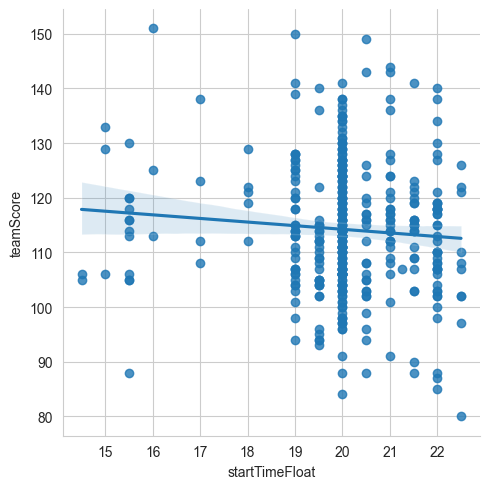

In [218]:
# sns.swarmplot(x='home', y='teamScore', data=timberwolves)
timberwolves['startTimeFloat'] = timberwolves['startTime'].apply(
    lambda t: t.hour + t.minute / 60 + t.second / 3600
)
sns.lmplot(x='startTimeFloat', y='teamScore', data=timberwolves)

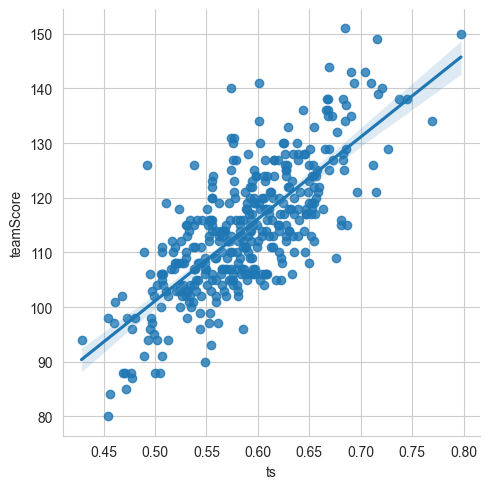

In [219]:
sns.lmplot(x='ts', y='teamScore', data=timberwolves)

<Axes: >

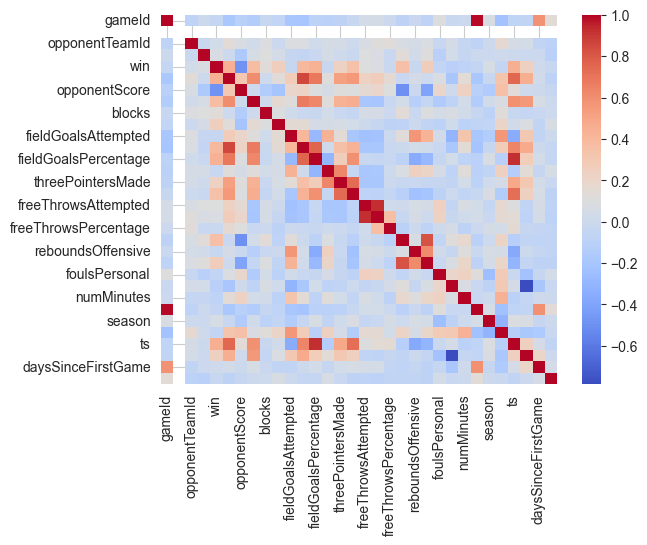

In [220]:
numeric_cols = timberwolves.select_dtypes(include='number')
# print(numeric_cols.columns)

sns.heatmap(numeric_cols.corr(), cmap='coolwarm')

### Ok, nothing jumping out right now so lets try and bring in some player data and see how that goes

In [237]:
players_stats_df['playerName'] = players_stats_df['firstName'].str.cat(players_stats_df['lastName'], sep=' ')

game_id = recent_team_stats[(recent_team_stats['gameDay'] == '2025-11-24') & (recent_team_stats['teamId'] == name_to_id['Timberwolves'])]['gameId'].iloc[0]

players_stats_df[(players_stats_df['gameId'] == game_id) & (players_stats_df['playerteamName'] == 'Timberwolves')][['playerName', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'plusMinusPoints']]

# ok so if a player gets no minutes then they have a NaN
# what about if a player is injured and misses the game?

,playerName,numMinutes,points,assists,reboundsTotal,plusMinusPoints
4,Donte DiVincenzo,37.03,17.0,1.0,4.0,6.0
7,Naz Reid,23.27,15.0,0.0,7.0,0.0
8,Anthony Edwards,40.15,43.0,4.0,7.0,-12.0
10,Jaden McDaniels,37.16,6.0,2.0,8.0,-6.0
12,Bones Hyland,NaN,0.0,0.0,0.0,0.0
14,Terrence Shannon Jr.,7.23,0.0,0.0,1.0,-4.0
15,Johnny Juzang,NaN,0.0,0.0,0.0,0.0
18,Leonard Miller,NaN,0.0,0.0,0.0,0.0
23,Jaylen Clark,6.25,0.0,0.0,3.0,1.0
26,Rob Dillingham,8.48,0.0,3.0,0.0,0.0


In [ ]:
#lets get the last game before lebron came back from siatica
game_id = recent_team_stats[(recent_team_stats['gameDay'] == '2025-11-15') & (recent_team_stats['teamId'] == name_to_id['Lakers'])]['gameId'].iloc[0]

players_stats_df[(players_stats_df['gameId'] == game_id) & (players_stats_df['playerteamName'] == 'Lakers')][['playerName', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'plusMinusPoints']]

#ok so if they were injured they dont show up? Lakers injury report before this game had bron, rui, and gabe vincent on it all of whom are missing from this

,playerName,numMinutes,points,assists,reboundsTotal,plusMinusPoints
1784,Maxi Kleber,25.01,3.0,3.0,1.0,22.0
1788,Jarred Vanderbilt,7.43,0.0,1.0,1.0,-11.0
1789,Deandre Ayton,28.26,20.0,0.0,10.0,12.0
1790,Luka Doncic,38.13,41.0,6.0,9.0,25.0
1793,Jaxson Hayes,16.41,10.0,1.0,6.0,10.0
1801,Austin Reaves,36.08,25.0,8.0,6.0,14.0
1807,Jake LaRavia,36.32,4.0,1.0,6.0,26.0
1809,Nick Smith Jr.,2.53,3.0,1.0,0.0,2.0
1814,Dalton Knecht,33.48,9.0,1.0,6.0,24.0
1816,Bronny James,9.54,0.0,1.0,1.0,-6.0


In [ ]:

#lets just confirm with another game but maybe from last season this time to see if its consistent
#the 76ers were kinda in injury purgatory last year so lets take the 2024-12-21 game vs the cavs
#injury report was jared mccain and joel embiid
game_id = recent_team_stats[(recent_team_stats['gameDay'] == '2024-12-21') & (recent_team_stats['teamId'] == name_to_id['76ers'])]['gameId'].iloc[0]

players_stats_df[(players_stats_df['gameId'] == game_id) & (players_stats_df['playerteamName'] == '76ers')][['playerName', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'plusMinusPoints']]

#ok looks like if a player is out theyre dropped from that game report
#so I can get how many players are missing by doing 15 - num_players
#but also role players matter slightly less so I should try and also have this weighted towards number of minutes missing, which would be done with min_per_game per season


,playerName,numMinutes,points,assists,reboundsTotal,plusMinusPoints
33493,Kelly Oubre Jr.,27.17,9.0,0.0,5.0,-34.0
33506,Guerschon Yabusele,22.42,7.0,1.0,3.0,-14.0
33521,Caleb Martin,28.58,8.0,3.0,3.0,-10.0
33536,Tyrese Maxey,33.00,27.0,3.0,1.0,-24.0
33543,Kenyon Martin Jr.,27.07,7.0,1.0,7.0,-6.0
33547,Jeff Dowtin Jr.,12.00,9.0,1.0,0.0,-4.0
33577,Adem Bona,11.39,3.0,1.0,3.0,-4.0
33578,Ricky Council IV,21.28,11.0,0.0,5.0,-10.0
33595,Kyle Lowry,4.34,0.0,2.0,1.0,-2.0
33598,Eric Gordon,9.40,7.0,0.0,0.0,-9.0


In [ ]:
all_rec_game_ids = recent_team_stats['gameId'].unique()
len(all_rec_game_ids)
recent_player_stats = players_stats_df[players_stats_df['gameId'].isin(all_rec_game_ids)]

144655